# Notebook 3: Cluster Optimization and Base Math
The Goal: Address finding the right number of clusters (K) and validating the high-dimensional feature space using linear algebra before baseline projection.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
abt = pd.read_parquet('../data/gold/model_input.parquet').sample(10000, random_state=42)

feature_cols = [
    "poi_total_catchment", "Tuition_Weekend_Surge", "Tourist_Peak_Multiplier", 
    "Sports_Big_Match_Spike", "Park_Poya_Outing", "Number_of_Weekends", "Holiday_Count"
]
X = abt[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Plot 1: The Elbow Method (WCSS)

/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_97688/1113141601.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K_range, wcss, 'bo-', color='#1f77b4')


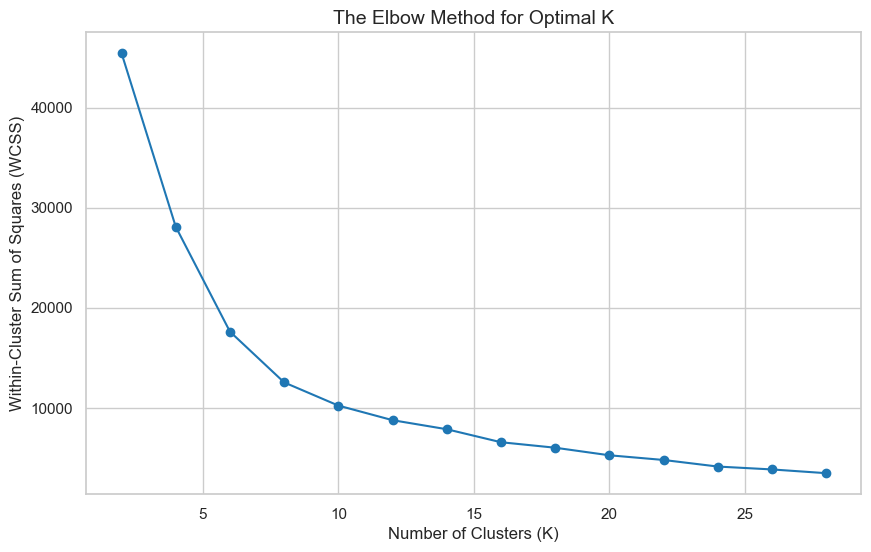

In [2]:
wcss = []
K_range = range(2, 30, 2)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', color='#1f77b4')
plt.title('The Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()


### Plot 2: 2D Principal Component Analysis (PCA) Projection

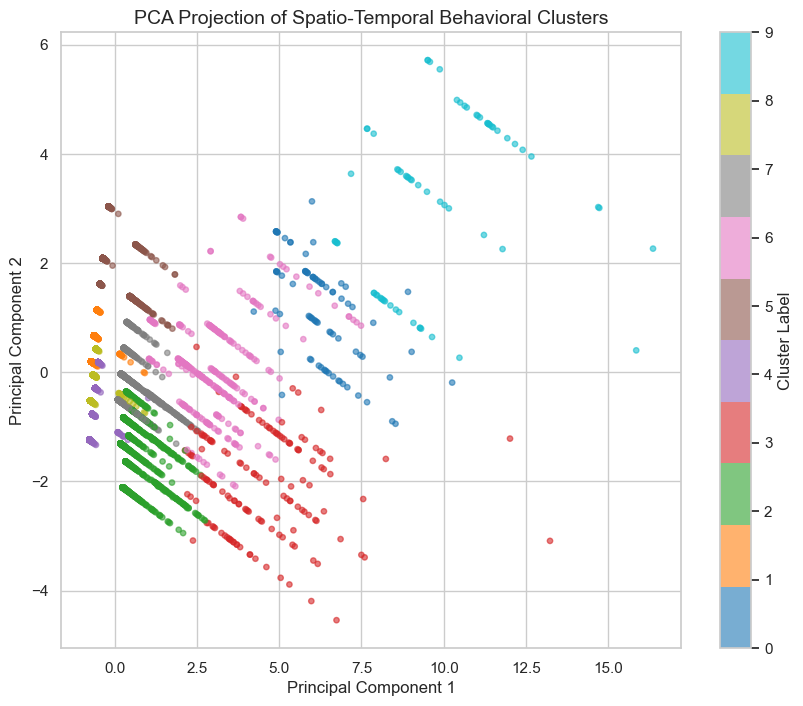

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
kmeans_final = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_final.labels_, cmap='tab10', alpha=0.6, s=15)
plt.title("PCA Projection of Spatio-Temporal Behavioral Clusters", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Cluster Label")
plt.show()


### Plot 3: The Empirical Ceiling (Decensoring)

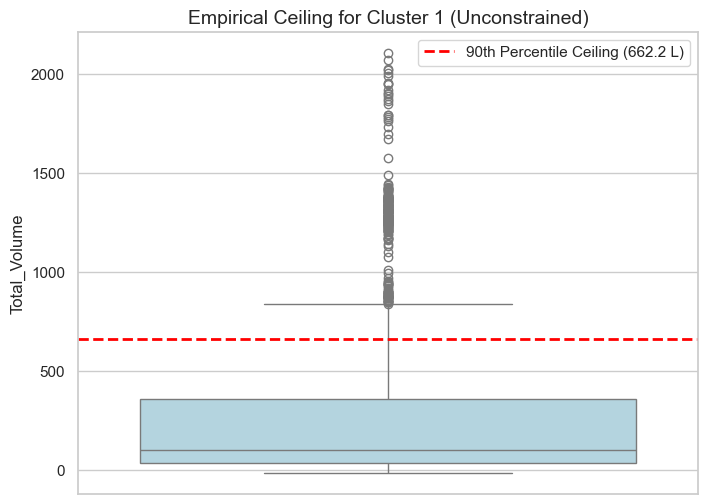

In [4]:
abt['Cluster'] = kmeans_final.labels_
cluster_1 = abt[(abt['Cluster'] == 1) & (abt['Is_Censored'] == 0)]
p90 = cluster_1['Total_Volume'].quantile(0.90)

plt.figure(figsize=(8, 6))
sns.boxplot(y=cluster_1['Total_Volume'], color='lightblue')
plt.axhline(p90, color='red', linestyle='--', linewidth=2, label=f'90th Percentile Ceiling ({p90:.1f} L)')
plt.title("Empirical Ceiling for Cluster 1 (Unconstrained)", fontsize=14)
plt.legend()
plt.show()
